## Imports

In [100]:
from __future__ import annotations

import json
import hashlib
from collections import OrderedDict
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import yaml



import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

try:
    from src.game.constants import COLOR_MAP
except Exception:
    COLOR_MAP = {
        "R": (0.85, 0.25, 0.25),
        "G": (0.25, 0.75, 0.35),
        "B": (0.30, 0.45, 0.90),
        "Y": (0.95, 0.85, 0.30),
        "BK": (0.0, 0.0, 0.0),
        "LG": (0.92, 0.92, 0.92),
        "W": (1.0, 1.0, 1.0),
    }

# Slightly lightened grid colours (halfway between original and previous pale version)
GRID_COLOR_MAP = {
    "R": (0.88, 0.30, 0.30),
    "G": (0.25, 0.75, 0.35),
    "B": (0.36, 0.50, 0.91),
    "Y": (0.96, 0.88, 0.42),
    "BK": (0.10, 0.10, 0.10),
    "LG": (0.93, 0.93, 0.93),
    "W": (1.0, 1.0, 1.0),
}

# Display names for contract types (log name -> readable label)
CONTRACT_DISPLAY_NAMES = {
    "none": "No Contract",
    "tile_with_judge_implementation": "NL-Trading",
    "strict": "Prog-Trading",
    "contract_for_finishing": "Prog-Points",
}

# Display names for bucket directories
BUCKET_DISPLAY_NAMES = {
    "Mutual_Dependency": "Mutually Dependent",
    "Needy_Player_Blue": "Asymmetric",
    "Independent_Both_have_optimal_paths": "Independent Both have optimal paths",
}

BUCKET_DIRS = [
    "Mutual_Dependency",
    "Needy_Player_Blue",
    "Independent_Both_have_optimal_paths",
]

DEFAULT_FONT_SIZE = 12
mpl.rcParams.update({
    "font.family":'monospace'
})

_REMAPPED_ID_CACHE: dict[int, int] | None = None


# Draw Routes

In [166]:

@dataclass(frozen=True)
class RunRoute:
    model_pair: str
    log_path: Path
    grid: list[list[str]]
    route_red: list[tuple[int, int]]
    route_blue: list[tuple[int, int]]


def _model_name(model_pair: str) -> str:
    """Extract the model name from a model pair string (e.g. 'HAIKU_4_5-HAIKU_4_5' -> 'Haiku-4.5')."""
    model_map = {
        "FOUR_1": "GPT-4.1",
        "HAIKU_4_5": "Haiku-4.5",
        "LLAMA_MAVERICK": "LLaMA Maverick",
        "LLAMA_SCOUT": "LLaMA Scout",
        "QWEN_3_235B": "Qwen-3-235B",
        "QWEN_3_30B": "Qwen-3-30B"
        }
    
    model_name = model_pair.split("-", 1)[0]
    return model_map.get(model_name, model_name)


def _parse_coord(x: Any) -> tuple[int, int]:
    if isinstance(x, (list, tuple)) and len(x) == 2:
        return int(x[0]), int(x[1])
    if isinstance(x, dict) and "r" in x and "c" in x:
        return int(x["r"]), int(x["c"])
    if isinstance(x, str) and "," in x:
        r, c = x.split(",", 1)
        return int(r.strip()), int(c.strip())
    raise ValueError(f"Unrecognized coordinate format: {x!r}")


def _load_remapped_ids(
    config_path: str | Path = "configs/experiment_configs/4x4_experiment_grids_reduced.yaml",
) -> dict[int, int]:
    """Load grid id -> remapped_id mapping from the YAML config. Cached after first call."""
    global _REMAPPED_ID_CACHE
    if _REMAPPED_ID_CACHE is not None:
        return _REMAPPED_ID_CACHE
    with open(config_path, "r") as f:
        grids = yaml.safe_load(f)
    _REMAPPED_ID_CACHE = {g["id"]: g["remapped_id"] for g in grids}
    return _REMAPPED_ID_CACHE


def _display_grid_id(grid_id: int) -> str:
    """Return 'Board XX' using the remapped_id, falling back to grid_id if not found."""
    mapping = _load_remapped_ids()
    display_id = mapping.get(grid_id, grid_id)
    return f"Board {display_id}"


def _extract_routes_from_event_log(data: dict) -> tuple[list[tuple[int, int]], list[tuple[int, int]]]:
    players = (((data.get("game") or {}).get("final_state") or {}).get("players") or {})
    p0 = players.get("0") or {}
    p1 = players.get("1") or {}
    r0 = p0.get("route") or []
    r1 = p1.get("route") or []
    return ([_parse_coord(x) for x in r0], [_parse_coord(x) for x in r1])


def _extract_grid_from_event_log(data: dict) -> list[list[str]]:
    game = data.get("game", {})
    for path in (
        ("config", "grid"),
        ("grid", "tiles"),
        ("grid", "tile_colors"),
        ("initial_state", "grid"),
        ("final_state", "grid"),
    ):
        cur: Any = game
        ok = True
        for k in path:
            if isinstance(cur, dict) and k in cur:
                cur = cur[k]
            else:
                ok = False
                break
        if ok and isinstance(cur, list) and cur and isinstance(cur[0], list):
            return cur
    raise KeyError("Could not find grid in event log JSON (tried several paths).")


def _extract_grid_from_metadata(sibling_metadata_json: Path) -> list[list[str]]:
    with sibling_metadata_json.open("r") as f:
        md = json.load(f)
    grid = md.get("grid")
    if not (isinstance(grid, list) and grid and isinstance(grid[0], list)):
        raise KeyError(f"metadata.json does not contain a valid 'grid': {sibling_metadata_json}")
    return grid


def _has_insufficient_credits(log_path: Path) -> bool:
    text = log_path.read_text()
    return "Insufficient credits" in text


def find_grid_runs(
    base_dir: str | Path,
    grid_id: int,
    config_dir: str = "ctx1_fog00_p4pfalse_contract_none_selfish11",
) -> tuple[list[Path], str]:
    base_dir = Path(base_dir)
    grid_dir = f"grid_{grid_id:03d}"
    for bucket_dir in BUCKET_DIRS:
        pattern = f"*/{bucket_dir}/{grid_dir}/{config_dir}/**/event_log_grid_{grid_id}_*.json"
        paths = sorted(base_dir.glob(pattern))
        if paths:
            paths = [p for p in paths if not _has_insufficient_credits(p)]
            return paths, bucket_dir
    return [], "UNKNOWN"


def load_run_routes(log_path: Path) -> RunRoute:
    with log_path.open("r") as f:
        data = json.load(f)

    try:
        model_pair = log_path.parts[log_path.parts.index("reduced_config_runs") + 1]
    except Exception:
        model_pair = "UNKNOWN"

    metadata_path = log_path.parent / "metadata.json"
    if metadata_path.exists():
        grid = _extract_grid_from_metadata(metadata_path)
    else:
        grid = _extract_grid_from_event_log(data)

    route_red, route_blue = _extract_routes_from_event_log(data)
    return RunRoute(model_pair=model_pair, log_path=log_path, grid=grid, route_red=route_red, route_blue=route_blue)


def _normalize_rgba(x):
    if isinstance(x, str):
        return x
    if isinstance(x, (tuple, list)) and len(x) in (3, 4):
        vals = [float(v) for v in x]
        if any(v > 1.0 for v in vals):
            vals = [v / 255.0 for v in vals]
        vals = [min(1.0, max(0.0, v)) for v in vals]
        return tuple(vals)
    return x


def _stable_unit_float(key: str) -> float:
    h = hashlib.md5(key.encode("utf-8")).hexdigest()
    return int(h[:8], 16) / 16**8


def _jitter_for_run_and_player(log_path: Path, player_id: int, run_jitter: float, player_sep: float) -> tuple[float, float]:
    key = str(log_path)
    u1 = _stable_unit_float(key + "|x")
    u2 = _stable_unit_float(key + "|y")
    jx = (u1 - 0.5) * 2 * run_jitter
    jy = (u2 - 0.5) * 2 * run_jitter

    if player_id == 0:
        jx -= player_sep
        jy -= player_sep
    else:
        jx += player_sep
        jy += player_sep
    return jx, jy

import numpy as np

def _polyline_wiggle(points: np.ndarray, amp: float, phase: float) -> np.ndarray:
    if len(points) < 2 or amp <= 0:
        return points

    segs = points[1:] - points[:-1]
    seglens = np.sqrt((segs**2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seglens)])
    total = s[-1]
    if total <= 1e-9:
        return points

    tang = np.zeros_like(points)
    tang[1:-1] = points[2:] - points[:-2]
    tang[0] = points[1] - points[0]
    tang[-1] = points[-1] - points[-2]
    tnorm = np.linalg.norm(tang, axis=1, keepdims=True)
    tang = np.divide(tang, tnorm, out=np.zeros_like(tang), where=tnorm > 1e-9)

    normals = np.stack([-tang[:, 1], tang[:, 0]], axis=1)

    k = 2 * np.pi * 2.5
    wig = amp * np.sin(k * (s / total) + phase)
    return points + normals * wig[:, None]


def _bezier_chain(points: np.ndarray, tension: float = 0.35, samples_per_seg: int = 25) -> np.ndarray:
    n = len(points)
    if n < 2:
        return points
    if n == 2:
        t = np.linspace(0, 1, samples_per_seg)
        return (1 - t)[:, None] * points[0] + t[:, None] * points[1]

    curve_pts = []
    for i in range(n - 1):
        p0 = points[i]
        p3 = points[i + 1]

        if i == 0:
            d0 = points[i + 1] - points[i]
        else:
            d0 = points[i + 1] - points[i - 1]
        if i + 2 >= n:
            d1 = points[i + 1] - points[i]
        else:
            d1 = points[i + 2] - points[i]

        p1 = p0 + tension * d0
        p2 = p3 - tension * d1

        t = np.linspace(0, 1, samples_per_seg, endpoint=False)
        seg = (
            ((1 - t) ** 3)[:, None] * p0
            + (3 * (1 - t) ** 2 * t)[:, None] * p1
            + (3 * (1 - t) * t ** 2)[:, None] * p2
            + (t ** 3)[:, None] * p3
        )
        curve_pts.append(seg)

    curve = np.vstack(curve_pts + [points[-1][None, :]])
    return curve

def _grid_to_rgb_image(grid: list[list[str]]) -> np.ndarray:
    n_rows = len(grid)
    n_cols = len(grid[0]) if n_rows else 0
    img = np.zeros((n_rows, n_cols, 3), dtype=float)

    for r in range(n_rows):
        for c in range(n_cols):
            col = grid[r][c]
            rgb = _normalize_rgba(GRID_COLOR_MAP.get(col, GRID_COLOR_MAP.get("LG", (0.93, 0.93, 0.93))))
            if isinstance(rgb, str):
                rgb = (0.93, 0.93, 0.93)
            img[r, c, :] = rgb[:3]
    return img


def _display_name(contract_type: str) -> str:
    return CONTRACT_DISPLAY_NAMES.get(contract_type, contract_type)


def _bucket_display_name(bucket: str) -> str:
    return BUCKET_DISPLAY_NAMES.get(bucket, bucket.replace("_", " "))


# High-contrast route colours — deep red and deep navy
ROUTE_COLOR_RED = "#B80000"    # deep true red
ROUTE_COLOR_BLUE = "#0022AA"   # deep navy blue


def _draw_routes_on_ax(
    ax,
    runs: list[RunRoute],
    mp_to_marker: dict[str, str],
    subtitle: str | None = None,
    run_jitter: float = 0.25,
    player_separation: float = 0.18,
    route_alpha: float = 0.15,
    route_linewidth: float = 2.8,
    endpoint_size: int = 128,
    wiggly: bool = True,
    wiggle_amp: float = 0.13,
    bezier_tension: float = 0.30,
):
    if not runs:
        return

    grid = runs[0].grid
    n_rows = len(grid)
    n_cols = len(grid[0]) if n_rows else 0

    img = _grid_to_rgb_image(grid)
    ax.imshow(img, origin="upper", extent=(0, n_cols, n_rows, 0), interpolation="nearest", zorder=0)

    for x in range(n_cols + 1):
        ax.vlines(x, 0, n_rows, colors="black", linewidth=0.8, alpha=0.75, zorder=1)
    for y in range(n_rows + 1):
        ax.hlines(y, 0, n_cols, colors="black", linewidth=0.8, alpha=0.75, zorder=1)

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    # ax.set_xticklabels([str(i) for i in range(n_cols)])
    # ax.set_yticklabels([str(i) for i in range(n_rows)])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=0)
    ax.set_xlabel("")
    ax.set_ylabel("")

    start_label_drawn = False
    start_cell = None  # (row, col) of the start cell

    def _route_xy(route, jx, jy):
        xs = [c + 0.5 + jx for (r, c) in route]
        ys = [r + 0.5 + jy for (r, c) in route]
        return xs, ys

    def _draw(route, *, color, marker, jx, jy, phase):
        nonlocal start_label_drawn, start_cell
        if not route:
            return

        start_r, start_c = route[0]
        centre_x = start_c + 0.5
        centre_y = start_r + 0.5
        depart_y = centre_y + 0.12
        xs, ys = _route_xy(route, jx, jy)
        xs[0] = centre_x
        ys[0] = depart_y
        pts = np.column_stack([xs, ys]).astype(float)

        if wiggly and len(pts) >= 2:
            pts2 = _polyline_wiggle(pts, amp=wiggle_amp, phase=phase)
            pts2[0] = [centre_x, depart_y]
            curve = _bezier_chain(pts2, tension=bezier_tension, samples_per_seg=30)
        else:
            curve = pts

        if len(curve) >= 2:
            ax.plot(
                curve[:, 0], curve[:, 1],
                color=color,
                alpha=route_alpha,
                linewidth=route_linewidth,
                linestyle="-",
                zorder=3,
            )

        if not start_label_drawn:
            start_label_drawn = True
            start_cell = (start_r, start_c)
            ax.text(
                centre_x, centre_y, "START",
                ha="center", va="center",
                fontsize=18, fontweight="bold", color="black",
                zorder=7,
            )

        # Place endpoint marker at the end of the rendered curve
        end_pt = curve[-1] if len(curve) >= 1 else pts[-1]

        # If the route finishes in the start cell, use jittered position
        # so multiple runs spread out instead of stacking.
        # Enforce a minimum radius from centre so markers don't land on "START" text.
        end_r, end_c = route[-1]
        if start_cell is not None and (end_r, end_c) == start_cell:
            dx = jx * 1.5
            dy = jy * 1.5
            dist = np.sqrt(dx**2 + dy**2)
            min_r = 0.4  # minimum distance from cell centre to avoid "START" text
            if dist < min_r and dist > 1e-6:
                dx *= min_r / dist
                dy *= min_r / dist
            elif dist <= 1e-6:
                dx = min_r
                dy = 0.0
            end_pt = np.array([end_c + 0.5 + dx, end_r + 0.5 + dy])

        ax.scatter(
            [end_pt[0]], [end_pt[1]],
            s=endpoint_size,
            color=color,
            marker=marker,
            alpha=0.95,
            edgecolors="k",
            linewidths=1.2,
            zorder=6,
        )

    for rr in runs:
        marker = mp_to_marker[rr.model_pair]
        jx0, jy0 = _jitter_for_run_and_player(rr.log_path, player_id=0, run_jitter=run_jitter, player_sep=player_separation)
        jx1, jy1 = _jitter_for_run_and_player(rr.log_path, player_id=1, run_jitter=run_jitter, player_sep=player_separation)

        phase = 2 * np.pi * _stable_unit_float(str(rr.log_path) + "|phase")

        _draw(rr.route_red, color=ROUTE_COLOR_RED, marker=marker, jx=jx0, jy=jy0, phase=phase)
        _draw(rr.route_blue, color=ROUTE_COLOR_BLUE, marker=marker, jx=jx1, jy=jy1, phase=phase + np.pi / 2)

    if subtitle:
        ax.set_title(subtitle, fontsize=1.75*DEFAULT_FONT_SIZE, pad=3)


def _contract_type_to_config_dir(contract_type: str, p4p: bool = False) -> str:
    ct = contract_type.strip().lower()
    if ct in {"none", "no", "no_contract"}:
        ct = "none"
    elif ct in {"for finishing", "for-finishing", "contract_for_finishing"}:
        ct = "contract_for_finishing"
    elif ct in {"tile", "tile_with_judge", "tile_with_judge_implementation", "tile-with-judge-implementation"}:
        ct = "tile_with_judge_implementation"
    elif ct in {"strict"}:
        ct = "strict"
    else:
        raise ValueError(
            f"Unknown contract_type={contract_type!r}. "
            "Use one of: none, contract_for_finishing, tile_with_judge_implementation, strict"
        )

    p4p_str = "true" if p4p else "false"
    return f"ctx1_fog00_p4p{p4p_str}_contract_{ct}_selfish11"


def _load_runs_for_contract(grid_id, contract_type, p4p, base_dir):
    config_dir = _contract_type_to_config_dir(contract_type=contract_type, p4p=p4p)
    log_paths, bucket_dir = find_grid_runs(base_dir=base_dir, grid_id=grid_id, config_dir=config_dir)
    print(f"Found {len(log_paths)} logs for grid {grid_id} | bucket={bucket_dir} | contract={_display_name(contract_type)}")
    runs = [load_run_routes(p) for p in log_paths]
    return runs, bucket_dir



def make_overlay_for_grid(
    grid_specs: list[dict],
    base_dir: str | Path = "public_logs/reduced_config_runs",
    p4p: bool = False,
    out_path: str | Path | None = None,
    run_jitter: float = 0.25,
    player_separation: float = 0.12,
    route_alpha: float = 0.55,
    route_linewidth: float = 2.8,
    wiggle_amp: float = 0.09,
    bezier_tension: float = 0.22,
    show: bool = True,
    n_rows: int | None = None,
    show_bucket_labels: bool = True,
):
    """
    Args:
        n_rows: If None, group by bucket (one row per bucket). If specified,
                ignore buckets and lay out all grids in this many rows.
        show_bucket_labels: If False, suppress the bucket type titles.
    """
    # ...existing code to load runs...
    spec_data = []
    all_runs = []
    for spec in grid_specs:
        grid_id = spec["grid_id"]
        ct1 = spec["contract_type_1"]
        ct2 = spec["contract_type_2"]
        runs_1, bucket_1 = _load_runs_for_contract(grid_id, ct1, p4p, base_dir)
        runs_2, bucket_2 = _load_runs_for_contract(grid_id, ct2, p4p, base_dir)
        bucket = bucket_1 if bucket_1 != "UNKNOWN" else bucket_2
        spec_data.append((spec, runs_1, runs_2, bucket))
        all_runs.extend(runs_1 + runs_2)

    
    model_pairs_unsorted = list({r.model_pair for r in all_runs})

    # Sort model_pairs by desired display-name order
    model_display_order = ["GPT-4.1", "Haiku-4.5", "LLaMA Maverick", "LLaMA Scout", "Qwen-3-235B", "Qwen-3-30B"]
    def _sort_key(mp):
        name = _model_name(mp)
        try:
            return model_display_order.index(name)
        except ValueError:
            return len(model_display_order)  # unknown models go last

    model_pairs = sorted(model_pairs_unsorted, key=_sort_key)

    markers = ['^', 's', 'D', 'P', 'X', '*', 'v', '<', '>', 'H']
    mp_to_marker = {mp: markers[i % len(markers)] for i, mp in enumerate(model_pairs)}

    # --- Layout: either group by bucket or use n_rows ---
    if n_rows is None:
        # Original behavior: group by bucket
        bucket_groups: OrderedDict[str, list] = OrderedDict()
        for entry in spec_data:
            bucket = entry[3]
            bucket_groups.setdefault(bucket, []).append(entry)
        # Convert to list of (label_or_None, entries)
        row_groups = [
            (bucket if show_bucket_labels else None, entries)
            for bucket, entries in bucket_groups.items()
        ]
    else:
        # Ignore buckets, distribute grids across n_rows rows
        import math
        grids_per_row = math.ceil(len(spec_data) / n_rows)
        row_groups = []
        for r in range(n_rows):
            start = r * grids_per_row
            end = min(start + grids_per_row, len(spec_data))
            entries = spec_data[start:end]
            if entries:
                row_groups.append((None, entries))

    actual_n_rows = len(row_groups)
    max_grids_per_row = max(len(entries) for _, entries in row_groups)

    # Build column width ratios
    PAIR_GAP = 0.05
    width_ratios = []
    for i in range(max_grids_per_row):
        if i > 0:
            width_ratios.append(PAIR_GAP)
        width_ratios.append(1)
        width_ratios.append(1)
    total_gs_cols = len(width_ratios)

    panel_size = 5
    fig_width = panel_size * (2 * max_grids_per_row) + panel_size * PAIR_GAP * max(0, max_grids_per_row - 1)
    fig_height = panel_size * actual_n_rows + 2.5

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(
        actual_n_rows, total_gs_cols,
        figure=fig,
        width_ratios=width_ratios,
        wspace=0.05,
        hspace=0.1,
    )

    draw_kwargs = dict(
        mp_to_marker=mp_to_marker,
        run_jitter=run_jitter,
        player_separation=player_separation,
        route_alpha=route_alpha,
        route_linewidth=route_linewidth,
        wiggle_amp=wiggle_amp,
        bezier_tension=bezier_tension,
    )

    for row_idx, (bucket_label, entries) in enumerate(row_groups):
        row_axes = []
        for grid_idx, (spec, runs_1, runs_2, _) in enumerate(entries):
            grid_id = spec["grid_id"]
            ct1 = spec["contract_type_1"]
            ct2 = spec["contract_type_2"]

            if grid_idx > 0:
                gs_col_left = grid_idx * 2 + grid_idx
            else:
                gs_col_left = 0
            gs_col_right = gs_col_left + 1

            ax_left = fig.add_subplot(gs[row_idx, gs_col_left])
            ax_right = fig.add_subplot(gs[row_idx, gs_col_right])

            row_axes.append(ax_left)
            row_axes.append(ax_right)

            _draw_routes_on_ax(
                ax_left, runs_1,
                subtitle=f"{_display_name(ct1)}",
                **draw_kwargs,
            )
            _draw_routes_on_ax(
                ax_right, runs_2,
                subtitle=f"{_display_name(ct2)}",
                **draw_kwargs,
            )

            # Grid ID label centred above the pair
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            bb_l = ax_left.get_window_extent(renderer).transformed(fig.transFigure.inverted())
            bb_r = ax_right.get_window_extent(renderer).transformed(fig.transFigure.inverted())
            pair_cx = (bb_l.x0 + bb_r.x1) / 2
            pair_top = max(bb_l.y1, bb_r.y1)
            fig.text(
                pair_cx, pair_top - 0.03,
                _display_grid_id(grid_id),
                ha="center", va="bottom",
                fontsize=1.25*DEFAULT_FONT_SIZE, fontweight="bold",
                transform=fig.transFigure,
            )

        # Bucket label (only if we have one)
        if bucket_label and row_axes:
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            bbs = [ax.get_window_extent(renderer).transformed(fig.transFigure.inverted()) for ax in row_axes]
            row_x0 = min(bb.x0 for bb in bbs)
            row_x1 = max(bb.x1 for bb in bbs)
            row_top = max(bb.y1 for bb in bbs)
            fig.text(
                (row_x0 + row_x1) / 2,
                row_top + 0.02,
                _bucket_display_name(bucket_label),
                ha="center", va="bottom",
                fontsize=16, fontweight="bold",
                transform=fig.transFigure,
            )

    # --- Legend (unchanged) ---
    # ...existing legend code...
    legend_font = DEFAULT_FONT_SIZE * 2

    board_handles = [
        Line2D([0], [0], marker="o", linestyle="None", color=ROUTE_COLOR_RED,
               markerfacecolor=ROUTE_COLOR_RED, markersize=11, label="P-Red"),
        Line2D([0], [0], marker="o", linestyle="None", color=ROUTE_COLOR_BLUE,
               markerfacecolor=ROUTE_COLOR_BLUE, markersize=11, label="P-Blue"),
    ]

    model_handles = [
        Line2D([0], [0], marker=mp_to_marker[mp], linestyle="None", color="k",
               markerfacecolor="0.7", markeredgecolor="k", markersize=11, label=_model_name(mp))
        for mp in model_pairs
    ]

    fig.canvas.draw()

    fig.subplots_adjust(bottom=0.01)  # was likely much larger or default
    leg_board = fig.legend(
        handles=board_handles,
        loc="lower center",
        bbox_to_anchor=(0.54, 0.06),
        ncol=len(board_handles),
        fontsize=legend_font,
        frameon=False,
        handletextpad=0.4,
        columnspacing=1.0,
    )
    fig.canvas.draw()
    bb = leg_board.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
    fig.text(
        bb.x0 - 0.01, bb.y0 + bb.height / 2,
        "Player:",
        fontsize=legend_font, fontweight="bold",
        ha="right", va="center", transform=fig.transFigure,
    )

    leg_model = fig.legend(
        handles=model_handles,
        loc="lower center",
        bbox_to_anchor=(0.54, 0.005),
        ncol=len(model_handles),
        fontsize=legend_font,
        frameon=False,
        handletextpad=0.4,
        columnspacing=1.0,
    )
    fig.canvas.draw()
    bb = leg_model.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
    fig.text(
        bb.x0 - 0.01, bb.y0 + bb.height / 2,
        "Model:",
        fontsize=legend_font, fontweight="bold",
        ha="right", va="center", transform=fig.transFigure,
    )

    fig.add_artist(leg_board)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bb1 = leg_board.get_window_extent(renderer).transformed(fig.transFigure.inverted())
    bb2 = leg_model.get_window_extent(renderer).transformed(fig.transFigure.inverted())

    pad = 0.012
    x0 = min(bb1.x0, bb2.x0) - 0.08
    y0 = min(bb1.y0, bb2.y0)
    x1 = max(bb1.x1, bb2.x1)
    y1 = max(bb1.y1, bb2.y1)

    box = FancyBboxPatch(
        (x0 - pad, y0 - pad),
        (x1 - x0) + 2 * pad,
        (y1 - y0) + 2 * pad,
        boxstyle="round,pad=0.001",
        facecolor="white",
        edgecolor="0.7",
        linewidth=1.0,
        transform=fig.transFigure,
        zorder=0,
    )
    fig.patches.append(box)

    if out_path is None:
        remapped_ids_str = "_".join(
            str(_load_remapped_ids().get(s["grid_id"], s["grid_id"]))
            for s in grid_specs
        )
        p4p_tag = 'p4p' if p4p else ''
        out_path = Path(f"analysis/figures/routes_boards_{remapped_ids_str}_{p4p_tag}.pdf")
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=250, bbox_inches="tight")
    print(f"Wrote {out_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


In [167]:
# # make_overlay_for_grid(
# #     grid_specs=[
# #         {"grid_id": 84, "contract_type_1": "none", "contract_type_2": "contract_for_finishing"},
# #         {"grid_id": 91, "contract_type_1": "none", "contract_type_2": "contract_for_finishing"},
# #         {"grid_id": 112, "contract_type_1": "none", "contract_type_2": "strict"},
# #         {"grid_id": 121, "contract_type_1": "none", "contract_type_2": "strict"},
# #     ],
# #     route_alpha=0.8,
# #     p4p=False
# # )

# make_overlay_for_grid(
#     grid_specs=[
#         {"grid_id": 82, "contract_type_1": "none", "contract_type_2": "strict"},
#         {"grid_id": 85, "contract_type_1": "none", "contract_type_2": "strict"},
#         {"grid_id": 112, "contract_type_1": "none", "contract_type_2": "strict"},
#         {"grid_id": 115, "contract_type_1": "none", "contract_type_2": "strict"},
#     ],
#     route_alpha=0.8,
#     p4p=True
# )

Found 10 logs for grid 82 | bucket=Mutual_Dependency | contract=No Contract
Found 7 logs for grid 82 | bucket=Mutual_Dependency | contract=Prog-Trading
Found 6 logs for grid 85 | bucket=Mutual_Dependency | contract=No Contract
Found 7 logs for grid 85 | bucket=Mutual_Dependency | contract=Prog-Trading
Found 6 logs for grid 115 | bucket=Needy_Player_Blue | contract=No Contract
Found 7 logs for grid 115 | bucket=Needy_Player_Blue | contract=Prog-Trading
Wrote analysis/figures/routes_boards_22_25_51_p4p.pdf


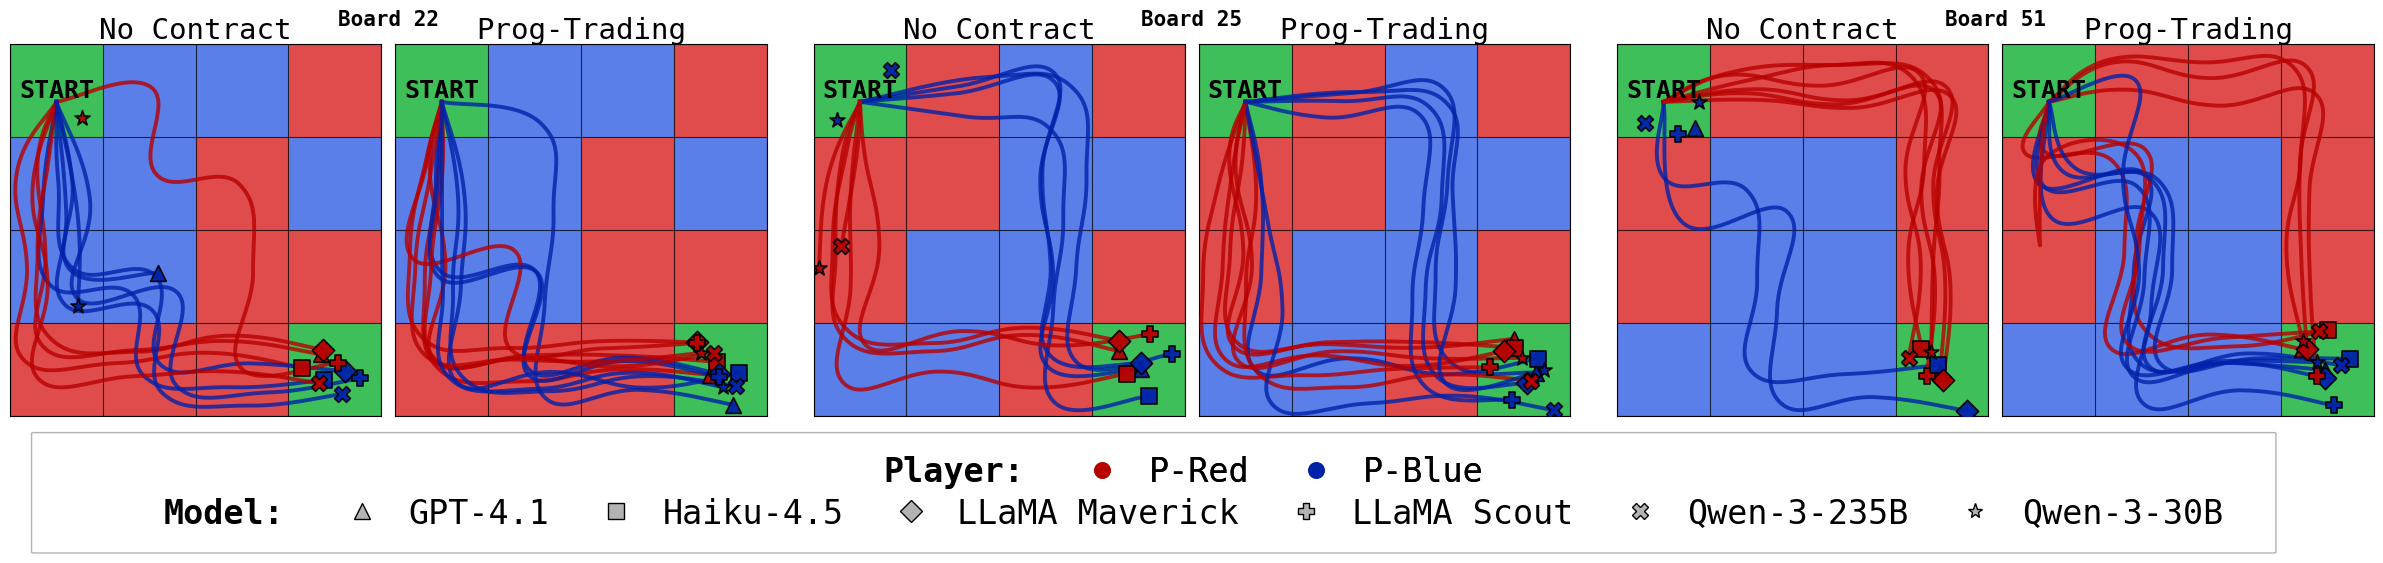

In [168]:


make_overlay_for_grid(
    grid_specs=[
        {"grid_id": 82, "contract_type_1": "none", "contract_type_2": "strict"},
        {"grid_id": 85, "contract_type_1": "none", "contract_type_2": "strict"},
        # {"grid_id": 112, "contract_type_1": "none", "contract_type_2": "strict"},
        {"grid_id": 115, "contract_type_1": "none", "contract_type_2": "strict"},
    ],
    route_alpha=0.8,
    p4p=True,
    n_rows=1, show_bucket_labels=False,
)

In [91]:


# make_overlay_for_grid(
#     grid_specs=[
#         {"grid_id": 92, "contract_type_1": "none", "contract_type_2": "contract_for_finishing"},
#         {"grid_id": 99, "contract_type_1": "none", "contract_type_2": "contract_for_finishing"},
#     ],
#     route_alpha=0.8,
#     p4p=True,
#     n_rows=1, show_bucket_labels=False
# )

# Draw Boards

In [ ]:


def _bucket_for_grid_id(grid_id: int) -> str:
    if grid_id < 20:
        return "Independent"
    elif grid_id < 40:
        return "Mutually Dependent"
    else:
        return "Asymmetric"


def draw_grids(
    grid_ids: list[int],
    config_path: str | Path = "configs/experiment_configs/4x4_experiment_grids_reduced.yaml",
    show: bool = True,
    ncols: int | None = None,
    cell_size: float = 1.8,
    label_fontsize: int = 12,
    bucket_label_fontsize: int = 16,
    board_id_fontsize: int = 14,
    title_gap: float = 0.4,   # inches reserved for each bucket title
):
    """Draw boards by ID, grouped by bucket with horizontal centered titles."""
    config_path = Path(config_path)
    with config_path.open("r") as f:
        all_grids = yaml.safe_load(f)

    id_to_grid = {g["remapped_id"]: g["grid"] for g in all_grids}

    # Group grid_ids by bucket
    bucket_order = ["Independent", "Mutually Dependent", "Asymmetric"]
    bucket_to_ids: dict[str, list[int]] = {b: [] for b in bucket_order}
    for gid in sorted(grid_ids):
        b = _bucket_for_grid_id(gid)
        if b in bucket_to_ids:
            bucket_to_ids[b].append(gid)
    bucket_to_ids = {b: ids for b, ids in bucket_to_ids.items() if ids}

    if ncols is None:
        ncols = min(max(len(ids) for ids in bucket_to_ids.values()), 10)

    # Compute rows per bucket
    bucket_nrows = {b: int(np.ceil(len(ids) / ncols)) for b, ids in bucket_to_ids.items()}

    # Total figure height: grid rows + title gaps
    total_grid_rows = sum(bucket_nrows.values())
    n_buckets = len(bucket_to_ids)
    fig_width = cell_size * ncols
    fig_height = cell_size * total_grid_rows + title_gap * n_buckets

    fig = plt.figure(figsize=(fig_width, fig_height))

    # Outer gridspec: one section per bucket, separated by small gaps for titles
    # height_ratios: proportional to number of grid rows per bucket
    outer_ratios = []
    active_buckets = [b for b in bucket_order if b in bucket_to_ids]
    for b in active_buckets:
        outer_ratios.append(bucket_nrows[b])

    outer_gs = gridspec.GridSpec(
        nrows=n_buckets,
        ncols=1,
        figure=fig,
        height_ratios=outer_ratios,
        hspace=title_gap * n_buckets / fig_height + 0.12,  # just enough for titles
    )

    for bucket_idx, b in enumerate(active_buckets):
        ids = bucket_to_ids[b]
        nr = bucket_nrows[b]

        # Inner gridspec for this bucket's grids
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            nr, ncols,
            subplot_spec=outer_gs[bucket_idx],
            hspace=0.17,  # tight spacing between grid rows within a bucket
            wspace=0.15,
        )

        # Bucket title: centered above this bucket's grid area
        # Get the top of the outer subplot spec in figure coords
        bbox = outer_gs[bucket_idx].get_position(fig)
        fig.text(
            (bbox.x0 + bbox.x1) / 2,
             bbox.y1 + 0.0015*board_id_fontsize,
            b,
            ha="center", va="bottom",
            fontsize=bucket_label_fontsize,
            fontweight="bold",
        )

        for local_idx, gid in enumerate(ids):
            r = local_idx // ncols
            c = local_idx % ncols
            ax = fig.add_subplot(inner_gs[r, c])

            if gid not in id_to_grid:
                raise ValueError(f"Grid ID {gid} not found in {config_path}")

            grid = id_to_grid[gid]
            gr = len(grid)
            gc = len(grid[0])
            img = _grid_to_rgb_image(grid)
            ax.imshow(img, origin="upper", extent=(0, gc, gr, 0), interpolation="nearest", zorder=0)

            for x in range(gc + 1):
                ax.vlines(x, 0, gr, colors="black", linewidth=0.5, alpha=0.6, zorder=1)
            for y in range(gr + 1):
                ax.hlines(y, 0, gc, colors="black", linewidth=0.5, alpha=0.6, zorder=1)

            ax.set_xlim(0, gc)
            ax.set_ylim(gr, 0)
            ax.set_aspect("equal")
            ax.set_xticks([])
            ax.set_yticks([])

            if len(grid_ids) >= 10:
                start_text, goal_text = "S", "G"
                
            else:
                start_text, goal_text = "START", "GOAL"
            
            ax.set_title(f"{gid}", fontsize=board_id_fontsize, pad=2)
            ax.text(0.5, 0.5, start_text, ha="center", va="center",
                    fontsize=label_fontsize, color="black", zorder=7)
            ax.text(gc - 0.5, gr - 0.5, goal_text, ha="center", va="center",
                    fontsize=label_fontsize, color="black", zorder=7)

    if len(grid_ids) <= 4:
        out_path = Path(f"analysis/figures/grids_{'_'.join(str(gid) for gid in grid_ids)}.pdf")
    elif ncols == 20:
        out_path = Path(f"analysis/figures/colm_{len(grid_ids)}_boards.pdf]")
    else:
        out_path = Path(f"analysis/figures/{len(grid_ids)}_boards.pdf")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Wrote {out_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)




Wrote analysis/figures/30_boards.pdf


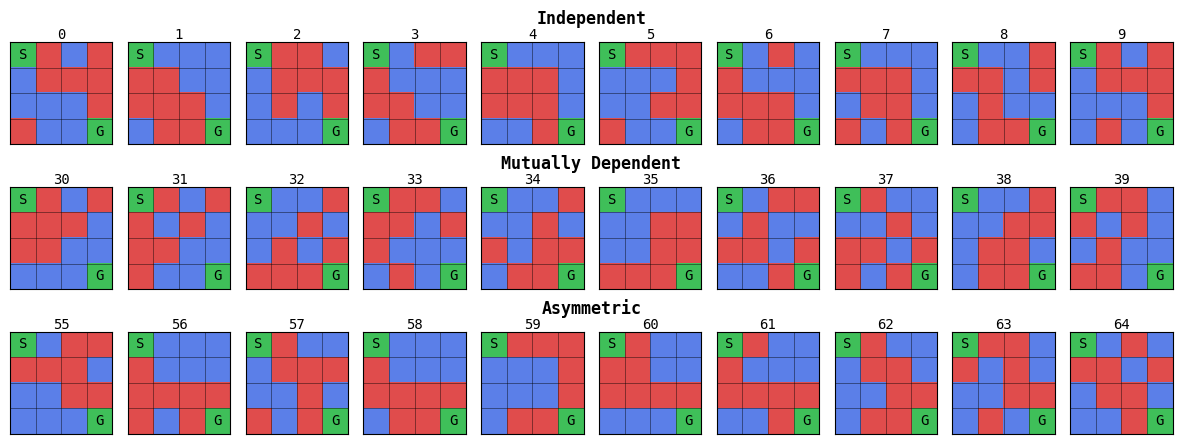

In [92]:
# Usage
draw_grids(list(range(10)) + list(range(30, 40)) + list(range(55, 65))
           , ncols=10, cell_size=1.5, label_fontsize=10, board_id_fontsize=10, bucket_label_fontsize = 12, title_gap= 0.25)


Wrote analysis/figures/80_boards.pdf


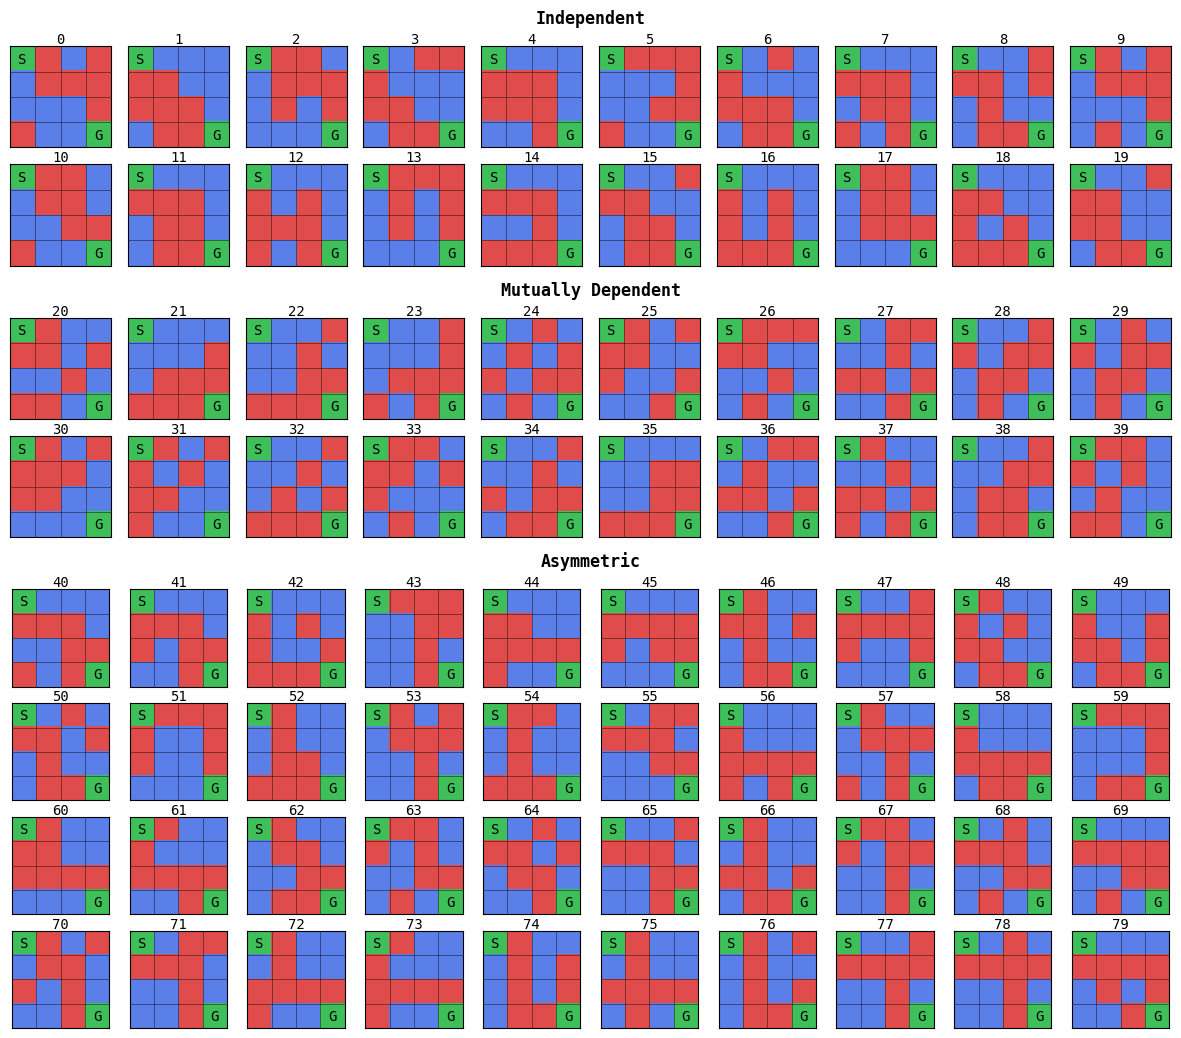

In [99]:
draw_grids(list(range(80))
           , ncols=10, cell_size=1.5, label_fontsize=10, board_id_fontsize=10, bucket_label_fontsize = 12, title_gap= 0.25)
